In [25]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical

In [26]:
import random


In [27]:
np.random.seed(0)

In [28]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()
X_train.shape
X_test.shape


(10000, 28, 28)

In [29]:
assert(X_train.shape[0]==y_train.shape[0]),"Somings wrong"

In [30]:
assert(X_train.shape[1:]==(28,28)),"naw the images wrong"

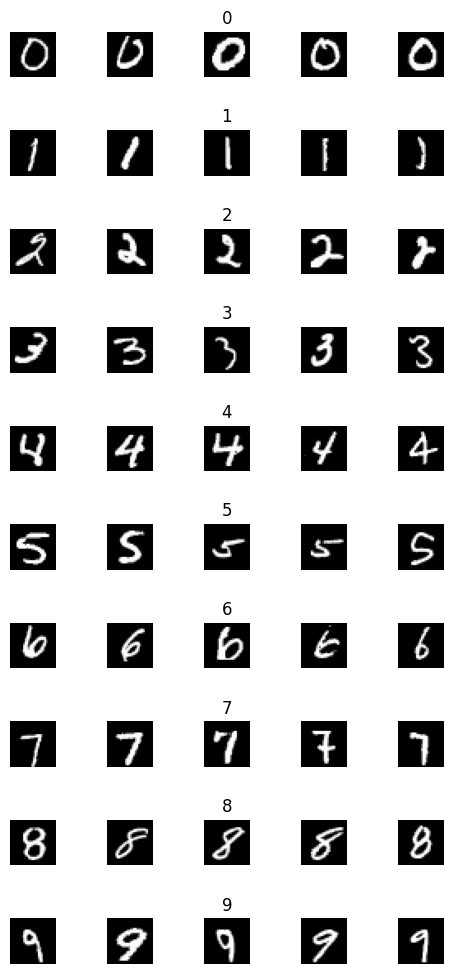

In [31]:
num_of_samples = []
num_of_classes=10

for i in range(num_of_classes):
    num_of_samples.append(np.sum(y_train == i))
cols=5


fig,axes=plt.subplots(nrows=num_of_classes,ncols=cols,figsize=(5,10))
fig.tight_layout()
for i in range(cols):
    for j in range(num_of_classes):
        x_selected=X_train[y_train==j]
        axes[j][i].imshow(x_selected[random.randint(0,len(x_selected-1)),:,:],cmap=plt.get_cmap("gray"))
        axes[j][i].axis("off")
        if i==2:
            axes[j][i].set_title(str(j))




[np.int64(5923), np.int64(6742), np.int64(5958), np.int64(6131), np.int64(5842), np.int64(5421), np.int64(5918), np.int64(6265), np.int64(5851), np.int64(5949)]


Text(0, 0.5, 'Number of images')

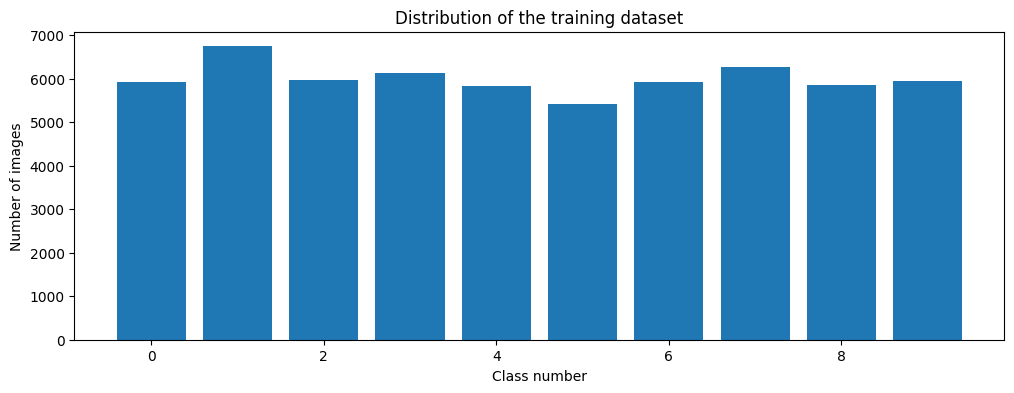

In [32]:
 print(num_of_samples)
 plt.figure(figsize=(12,4))
 plt.bar(range(0,num_of_classes),num_of_samples)
 plt.title("Distribution of the training dataset")
 plt.xlabel("Class number")
 plt.ylabel("Number of images")


In [33]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [34]:
X_train=X_train/255
X_test=X_test/255

In [35]:
num_pixels=784
X_train=X_train.reshape(X_train.shape[0],num_pixels)
X_test=X_test.reshape(X_test.shape[0],num_pixels)


In [36]:
num_classes=10
def create_model():
    model = Sequential()
    model.add(Dense(10, input_dim=num_pixels, activation='relu'))
    model.add(Dense(30, activation='relu'))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
    return model




In [37]:
model = create_model()
print(model.summary())



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,600 (33.59 KB)

 Trainable params: 8,600 (33.59 KB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8382 - loss: 0.5124 - val_accuracy: 0.9298 - val_loss: 0.2422
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9234 - loss: 0.2615 - val_accuracy: 0.9412 - val_loss: 0.2087
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9312 - loss: 0.2306 - val_accuracy: 0.9420 - val_loss: 0.1990
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9365 - loss: 0.2135 - val_accuracy: 0.9360 - val_loss: 0.2081
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9401 - loss: 0.1981 - val_accuracy: 0.9457 - val_loss: 0.1856
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9420 - loss: 0.1935 - val_accuracy: 0.9468 - val_loss: 0.1852
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9444 - loss: 0.1880 - val_accuracy: 0.9458 - val_loss: 0.1960
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9452 - loss: 0.1845 - val_accuracy: 0.

Text(0.5, 0, 'epoch')

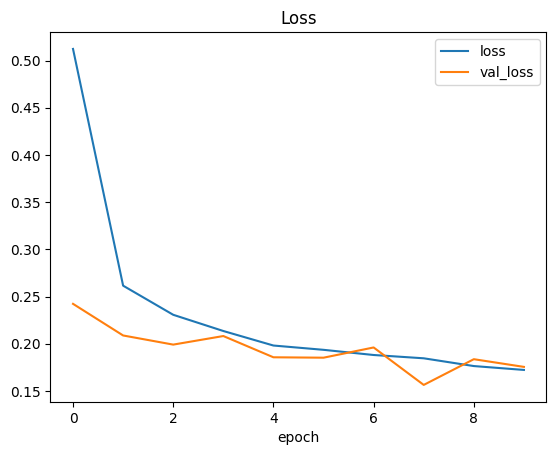

In [38]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs = 10, batch_size = 200, verbose = 1, shuffle = 1)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.xlabel('epoch')



Text(0.5, 0, 'epoch')

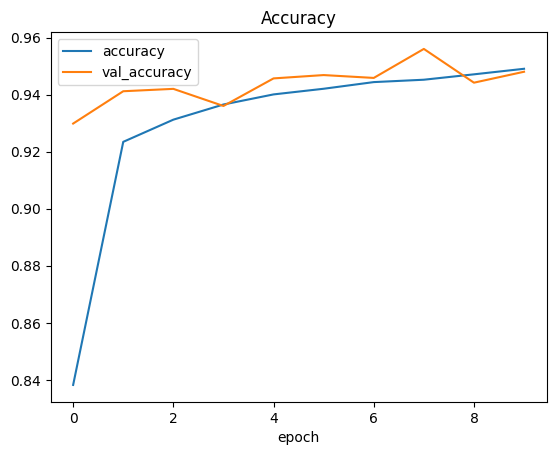

In [39]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.title('Accuracy')
plt.xlabel('epoch')


In [40]:

score = model.evaluate(X_test, y_test, verbose=0)
print(type(score))
print('Test score:', score[0])
print('Test accuracy:', score[1])



<class 'list'>
Test score: 0.20845165848731995
Test accuracy: 0.9395999908447266


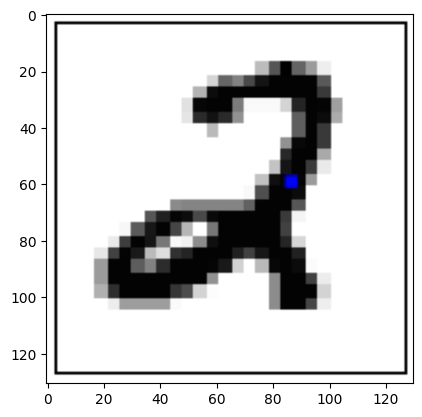

In [41]:
import requests
from PIL import Image

url = 'https://colah.github.io/posts/2014-10-Visualizing-MNIST/img/mnist_pca/MNIST-p1815-4.png'
response = requests.get(url, stream=True)
img = Image.open(response.raw)
plt.imshow(img, cmap=plt.get_cmap('gray'))



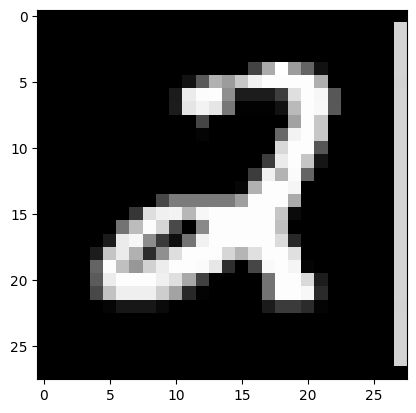

In [42]:
import cv2

img = np.asarray(img)
img = cv2.resize(img, (28, 28))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.bitwise_not(img)
plt.imshow(img, cmap=plt.get_cmap('gray'))



In [43]:
img = img/255
img = img.reshape(1, 784)

prediction = model.predict(img, verbose=0)
predicted_digit = np.argmax(prediction, axis=1)

print("Predicted digit:", predicted_digit[0])

Predicted digit: 2
